In [3]:
!pip install ultralytics
!pip install opencv-python
!pip install pyyaml

In [4]:
import os
import cv2
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

from sklearn.metrics import classification_report

In [4]:
zip_path = r"C:\Users\sumit\Downloads\axial MRI.v2-release.yolokeras.zip"
extract_path = "brain_tumor_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:

    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [5]:
import os
main_folder = os.path.join(
    "brain_tumor_dataset",
    "axial MRI.v2-release.yolokeras"
)

train_path = os.path.join(
    main_folder,
    "train"
)

valid_path = os.path.join(
    main_folder,
    "valid"
)

test_path = os.path.join(
    main_folder,
    "test"
)

print(os.path.exists(train_path))
print(os.path.exists(valid_path))
print(os.path.exists(test_path))

True
True
True


In [6]:
train_images = [

    file for file in os.listdir(train_path)

    if file.endswith(".jpg")
]

valid_images = [

    file for file in os.listdir(valid_path)

    if file.endswith(".jpg")
]

test_images = [

    file for file in os.listdir(test_path)

    if file.endswith(".jpg")
]

print("\nTrain Images:", len(train_images))

print("Validation Images:", len(valid_images))

print("Test Images:", len(test_images))


Train Images: 253
Validation Images: 79
Test Images: 39


In [7]:
import pandas as pd

train_annotations = pd.read_csv(

    os.path.join(
        train_path,
        "_annotations.csv"
    )
)

print(train_annotations.head())

  00305_113_jpg.rf.da8b7d0769c01e94571b568186f33347.jpg  150   91  167  106  1
0  00270_12_jpg.rf.e907a43bd4422aaa2d428b61aaaa2d...     111  226  157  269  1
1  00240_134_jpg.rf.dacd6bdae9ee803c1eed41507c352...      85   97  106  126  1
2  00099_154_jpg.rf.d9eb261c8c610b762f46f1e6f7cfc...      90  187  107  205  0
3  00097_77_jpg.rf.e3e5e35e8a02fc23abecb637702906...     159  151  192  188  0
4  00281_128_jpg.rf.ec0b341f8da42f413d3f4b2def6c2...     108   79  128  100  1


In [7]:
import pandas as pd

annotations = pd.read_csv(

    os.path.join(
        train_path,
        "_annotations.csv"
    ),

    header=None,

    names=[
        "filename",
        "xmin",
        "ymin",
        "xmax",
        "ymax",
        "class"
    ]
)

print(annotations.columns)

Index(['filename', 'xmin', 'ymin', 'xmax', 'ymax', 'class'], dtype='object')


In [8]:
print(annotations.head())

print("\nCOLUMN NAMES:\n")

print(list(annotations.columns))

                                            filename  xmin  ymin  xmax  ymax  \
0  00305_113_jpg.rf.da8b7d0769c01e94571b568186f33...   150    91   167   106   
1  00270_12_jpg.rf.e907a43bd4422aaa2d428b61aaaa2d...   111   226   157   269   
2  00240_134_jpg.rf.dacd6bdae9ee803c1eed41507c352...    85    97   106   126   
3  00099_154_jpg.rf.d9eb261c8c610b762f46f1e6f7cfc...    90   187   107   205   
4  00097_77_jpg.rf.e3e5e35e8a02fc23abecb637702906...   159   151   192   188   

   class  
0      1  
1      1  
2      1  
3      0  
4      0  

COLUMN NAMES:

['filename', 'xmin', 'ymin', 'xmax', 'ymax', 'class']


In [9]:
annotations = pd.read_csv(

    os.path.join(
        train_path,
        "_annotations.csv"
    ),

    header=None,

    names=[
        "filename",
        "xmin",
        "ymin",
        "xmax",
        "ymax",
        "class"
    ]
)

# CHECK DATA
print(annotations.head())

                                            filename  xmin  ymin  xmax  ymax  \
0  00305_113_jpg.rf.da8b7d0769c01e94571b568186f33...   150    91   167   106   
1  00270_12_jpg.rf.e907a43bd4422aaa2d428b61aaaa2d...   111   226   157   269   
2  00240_134_jpg.rf.dacd6bdae9ee803c1eed41507c352...    85    97   106   126   
3  00099_154_jpg.rf.d9eb261c8c610b762f46f1e6f7cfc...    90   187   107   205   
4  00097_77_jpg.rf.e3e5e35e8a02fc23abecb637702906...   159   151   192   188   

   class  
0      1  
1      1  
2      1  
3      0  
4      0  


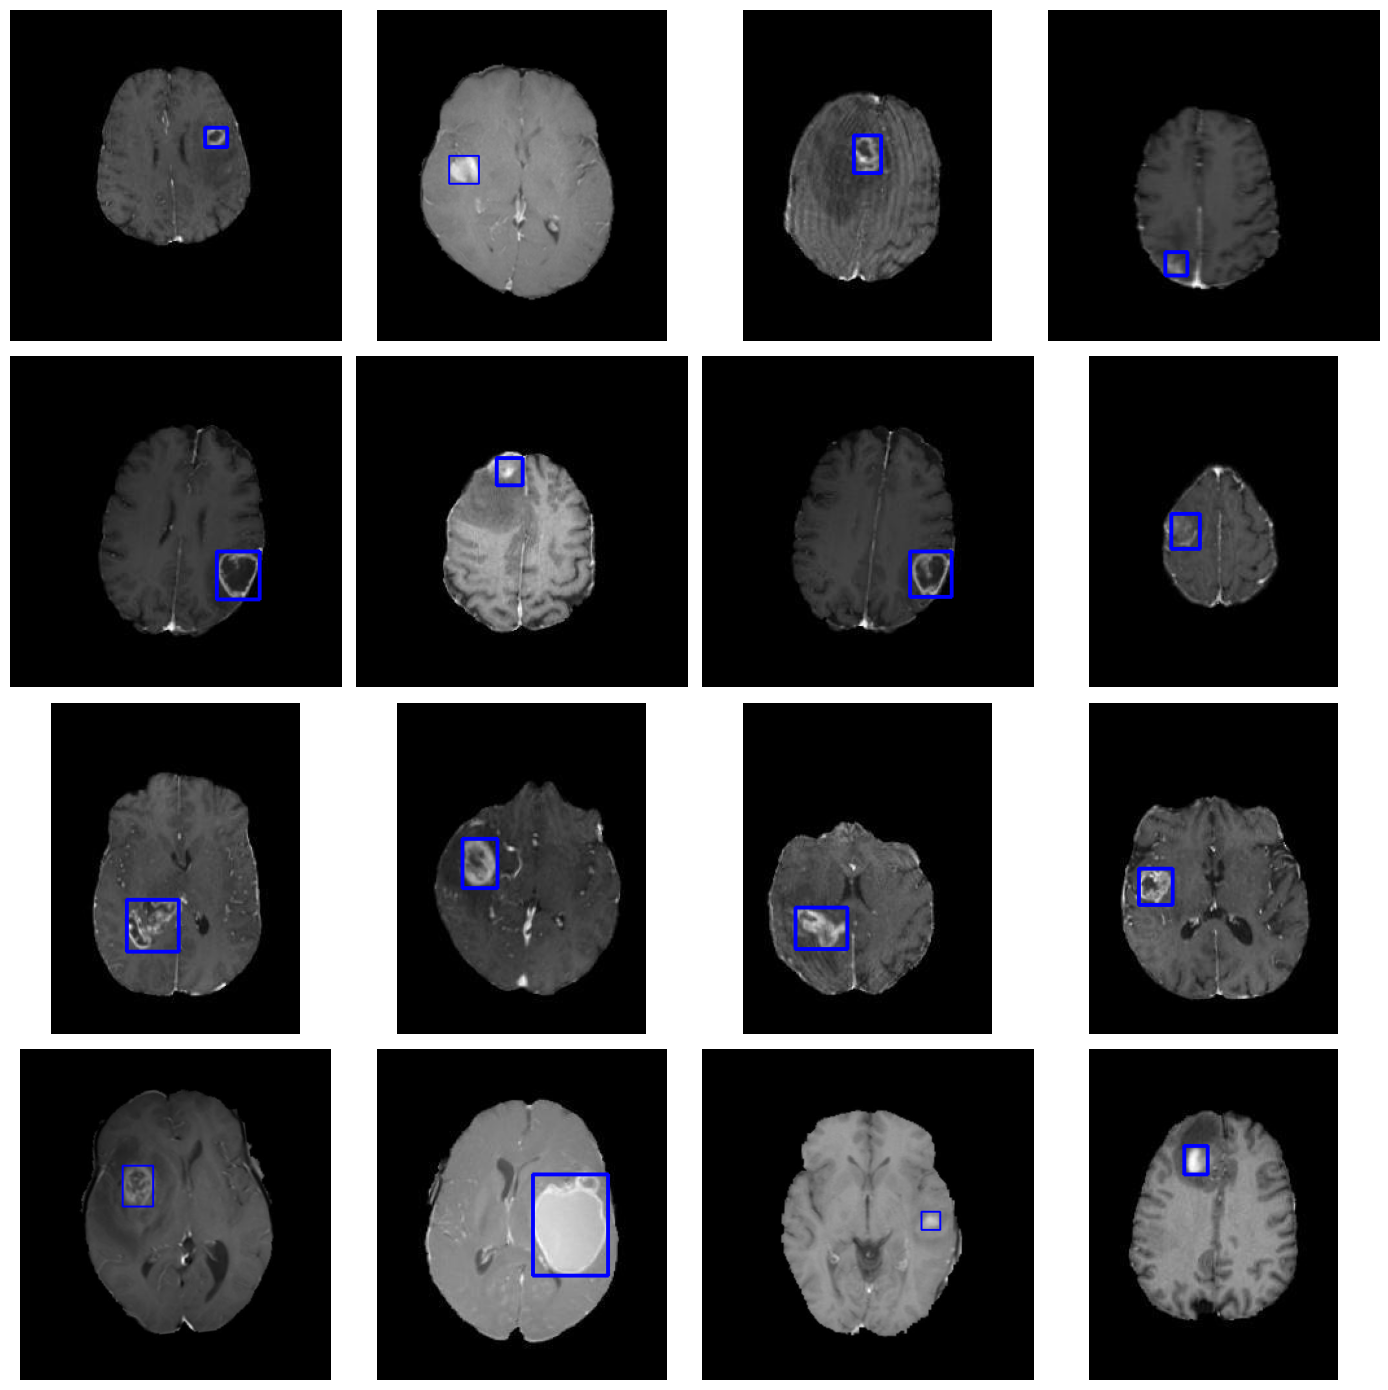

In [11]:
import cv2
import matplotlib.pyplot as plt

# GET IMAGE NAMES

image_names = annotations[
    "filename"
].unique()

# SHOW 16 IMAGES

plt.figure(figsize=(14,14))

for i in range(16):

    image_name = image_names[i]

    image_path = os.path.join(
        train_path,
        image_name
    )

    img = cv2.imread(image_path)

    if img is None:
        continue

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    rows = annotations[
        annotations["filename"] == image_name
    ]

    # Draw boxes
    for _, row in rows.iterrows():

        xmin = int(row["xmin"])
        ymin = int(row["ymin"])

        xmax = int(row["xmax"])
        ymax = int(row["ymax"])

        # BLUE BOX
        cv2.rectangle(

            img,

            (xmin, ymin),

            (xmax, ymax),

            (0,0,255),

            2
        )

    plt.subplot(4,4,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [10]:
import os
import cv2

# FUNCTION TO CREATE YOLO LABELS

def create_yolo_labels(folder_path):

    # Load CSV
    annotations = pd.read_csv(

        os.path.join(
            folder_path,
            "_annotations.csv"
        ),

        header=None,

        names=[
            "filename",
            "xmin",
            "ymin",
            "xmax",
            "ymax",
            "class"
        ]
    )

    # Create labels folder
    labels_folder = os.path.join(
        folder_path,
        "labels"
    )

    os.makedirs(
        labels_folder,
        exist_ok=True
    )

    # Unique image names
    image_names = annotations[
        "filename"
    ].unique()

    # PROCESS EACH IMAGE

    for image_name in image_names:

        image_path = os.path.join(
            folder_path,
            image_name
        )

        img = cv2.imread(image_path)

        if img is None:
            continue

        h, w, _ = img.shape

        rows = annotations[
            annotations["filename"] == image_name
        ]

        # Creating txt file
        txt_name = image_name.replace(
            ".jpg",
            ".txt"
        )

        txt_path = os.path.join(
            labels_folder,
            txt_name
        )

        with open(txt_path, "w") as f:

            for _, row in rows.iterrows():

                xmin = row["xmin"]
                ymin = row["ymin"]

                xmax = row["xmax"]
                ymax = row["ymax"]

                # CONVERTING TO YOLO FORMAT

                x_center = (
                    (xmin + xmax) / 2
                ) / w

                y_center = (
                    (ymin + ymax) / 2
                ) / h

                box_width = (
                    xmax - xmin
                ) / w

                box_height = (
                    ymax - ymin
                ) / h

                # Class = 0
                f.write(

                    f"0 {x_center} "
                    f"{y_center} "
                    f"{box_width} "
                    f"{box_height}\n"
                )

# CREATING LABELS FOR ALL FOLDERS

create_yolo_labels(train_path)

create_yolo_labels(valid_path)

print("YOLO Labels Created Successfully")


YOLO Labels Created Successfully


In [11]:
yaml_text = f"""

train: {train_path}
val: {valid_path}
test: {test_path}

nc: 1

names: ['tumor']
"""

with open("data.yaml", "w") as f:

    f.write(yaml_text)

print("data.yaml created successfully")

data.yaml created successfully


In [12]:
from ultralytics import YOLO

# LOADING BEST TRAINED MODEL

best_model = YOLO(

    "runs/detect/train/weights/best.pt"
)

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


In [13]:
from ultralytics import YOLO

# Load YOLOv8 nano
model = YOLO("yolov8n.pt")

# Train model
model.train(

    data="data.yaml",

    epochs=20,

    imgsz=640,

    batch=16
)

New https://pypi.org/project/ultralytics/8.4.55 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.54  Python-3.13.7 torch-2.12.0+cpu CPU (Intel Core i7-8565U 1.80GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000154821A1130>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [14]:
# GET TEST IMAGE LIST

test_images_list = [

    file for file in os.listdir(test_path)

    if file.endswith(".jpg")
]

print("Total Test Images:",
      len(test_images_list))

Total Test Images: 39


In [15]:
import matplotlib.pyplot as plt
import cv2

# SHOWING 16 PREDICTIONS

plt.figure(figsize=(14,14))

for i in range(16):

    image_name = test_images_list[i]

    image_path = os.path.join(
        test_path,
        image_name
    )

    # Read image
    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # PREDICT

    results = best_model.predict(

        image_path,

        conf=0.25
    )

    # DRAW PREDICTED BOXES

    for result in results:

        boxes = result.boxes

        for box in boxes:

            x1, y1, x2, y2 = map(

                int,

                box.xyxy[0]
            )

            # RED BOX
            cv2.rectangle(

                img,

                (x1, y1),

                (x2, y2),

                (255,0,0),

                2
            )

    # PLOT

    plt.subplot(4,4,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()

plt.show()


image 1/1 C:\Users\sumit\brain_tumor_dataset\axial MRI.v2-release.yolokeras\test\00306_109_jpg.rf.14014c8a4460a1f21b7f24d6b0c3fd7a.jpg: 640x480 (no detections), 106.9ms
Speed: 4.3ms preprocess, 106.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 C:\Users\sumit\brain_tumor_dataset\axial MRI.v2-release.yolokeras\test\00306_115_jpg.rf.91c4f9cd703fec2885778c34c52bd34a.jpg: 640x480 (no detections), 127.4ms
Speed: 4.0ms preprocess, 127.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 C:\Users\sumit\brain_tumor_dataset\axial MRI.v2-release.yolokeras\test\00306_92_jpg.rf.f6f1a5697229fd7dcb5a8a9c44cfb7e0.jpg: 640x480 (no detections), 88.3ms
Speed: 4.2ms preprocess, 88.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 C:\Users\sumit\brain_tumor_dataset\axial MRI.v2-release.yolokeras\test\00306_96_jpg.rf.c38afdeeadaf853872e03d0dea4d3489.jpg: 640x480 (no detections), 93.7ms
Speed: 2.5ms preprocess, 93.7ms

<Figure size 1400x1400 with 16 Axes>

In [16]:
import matplotlib.pyplot as plt
import cv2

# LOAD VALIDATION ANNOTATIONS

valid_annotations = pd.read_csv(

    os.path.join(
        valid_path,
        "_annotations.csv"
    ),

    header=None,

    names=[
        "filename",
        "xmin",
        "ymin",
        "xmax",
        "ymax",
        "class"
    ]
)

# UNIQUE IMAGE NAMES

image_names = valid_annotations[
    "filename"
].unique()

# GRID PLOT

plt.figure(figsize=(15,15))

for i in range(16):

    image_name = image_names[i]

    image_path = os.path.join(
        valid_path,
        image_name
    )

    # Read image
    img = cv2.imread(image_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )
   
    # DRAW ORIGINAL BOXES (BLUE)

    rows = valid_annotations[
        valid_annotations["filename"] == image_name
    ]

    for _, row in rows.iterrows():

        xmin = int(row["xmin"])
        ymin = int(row["ymin"])

        xmax = int(row["xmax"])
        ymax = int(row["ymax"])

        # BLUE BOX
        cv2.rectangle(

            img,

            (xmin, ymin),

            (xmax, ymax),

            (0,0,255),

            2
        )

    # YOLO PREDICTIONS

    results = best_model.predict(

        image_path,

        conf=0.25
    )

    # DRAW PREDICTED BOXES (RED)

    for result in results:

        boxes = result.boxes

        for box in boxes:

            x1, y1, x2, y2 = map(

                int,

                box.xyxy[0]
            )

            # RED BOX
            cv2.rectangle(

                img,

                (x1, y1),

                (x2, y2),

                (255,0,0),

                2
            )

    # SHOW IMAGE

    plt.subplot(4,4,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()

plt.show()


image 1/1 C:\Users\sumit\brain_tumor_dataset\axial MRI.v2-release.yolokeras\valid\00088_129_jpg.rf.120cc1c1222a77cff399fd92c2dc5420.jpg: 640x640 (no detections), 119.6ms
Speed: 7.0ms preprocess, 119.6ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sumit\brain_tumor_dataset\axial MRI.v2-release.yolokeras\valid\00084_123_jpg.rf.03700fc5f9628544351fa1e476c801a0.jpg: 640x640 (no detections), 123.0ms
Speed: 5.2ms preprocess, 123.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sumit\brain_tumor_dataset\axial MRI.v2-release.yolokeras\valid\00053_221_jpg.rf.14c316722cac0391dc885bddfb419134.jpg: 640x640 (no detections), 112.3ms
Speed: 5.6ms preprocess, 112.3ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 C:\Users\sumit\brain_tumor_dataset\axial MRI.v2-release.yolokeras\valid\00053_263_jpg.rf.123ba9b706e7ba8de3de99e8a3b4ff73.jpg: 640x640 (no detections), 109.1ms
Speed: 5.2ms preproces

<Figure size 1500x1500 with 16 Axes>